Data quality and missing values
Reporting coverage
Portability trends
Pearson and Spearman correlations
Card entitlement versus transactions
Rice/wheat distributions
District comparisons
Monthly seasonality
Utilization ratios
Outlier identification
Evidence-based summary metrics

In [2]:
import pandas as pd

monthly_data = pd.read_csv(r"C:\Users\balaj\OneDrive\Desktop\Telangana_PDS_Project\data\processed\monthly_unified.csv")
print("loaded shape:",monthly_data.shape)
monthly_data.head()

loaded shape: (517651, 39)


,distCode,distName,officeCode,officeName,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,...,officeName_location,address,longitude,latitude,fpsStatus,fpsType,total_rice,utilization_ratio,portability_ratio,rice_wheat_ratio
0,538,Mahbubnagar,538007.0,Koilkonda,1407001,1,2023,241.0,241.0,805.0,...,Koilkonda,SANKALAMADDI ANAND KUMAR KOILKONDA,77.789107,16.755785,Active,Normal Shop,5355.0,0.698551,0.141079,NaN
1,538,Mahbubnagar,538007.0,Koilkonda,1407001,1,2024,256.0,261.0,1225.0,...,Koilkonda,SANKALAMADDI ANAND KUMAR KOILKONDA,77.789107,16.755785,Active,Normal Shop,6781.0,NaN,0.149425,NaN
2,538,Mahbubnagar,538007.0,Koilkonda,1407001,1,2025,270.0,274.0,1120.0,...,Koilkonda,SANKALAMADDI ANAND KUMAR KOILKONDA,77.789107,16.755785,Active,Normal Shop,6910.0,0.794203,0.200730,NaN
3,538,Mahbubnagar,538007.0,Koilkonda,1407001,2,2023,258.0,259.0,910.0,...,Koilkonda,SANKALAMADDI ANAND KUMAR KOILKONDA,77.789107,16.755785,Active,Normal Shop,5750.0,0.750725,0.158301,NaN
4,538,Mahbubnagar,538007.0,Koilkonda,1407001,2,2024,278.0,281.0,1295.0,...,Koilkonda,SANKALAMADDI ANAND KUMAR KOILKONDA,77.789107,16.755785,Active,Normal Shop,7169.0,0.814493,0.188612,NaN


In [3]:
monthly_data["period"] = pd.to_datetime(monthly_data["period"], errors="coerce")
print("period_range:", monthly_data["period"].min(), "to" , monthly_data["period"].max())
print(monthly_data["period"].dtype)

period_range: 2023-01-01 00:00:00 to 2025-06-01 00:00:00
datetime64[us]


In [ ]:
#verify monthly keys and finding missing percentage 
# post preparation checks 
month_key = [
    "distCode",
    "shopNo",
    "year",
    "month"
]

print(
    "Repeated monthly keys:",
    monthly_data.duplicated(month_key
    ).sum()
)

print(
    "Missing monthly keys:",
    monthly_data[
        month_key
    ].isna().any(axis=1).sum()
)

print(
    "Invalid periods:",
    monthly_data[
        "period"
    ].isna().sum()
)


missing_values = pd.DataFrame({
    "missing_count": (
        monthly_data.isna().sum()
    ),

    "missing_percentage": (
        monthly_data.isna().mean()
        * 100
    ).round(2)
})

missing_values = (
    missing_values
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

missing_values.head(20)

In [5]:
#Create transaction EDA data


# simple checking with notnull values   vs null values 
transaction_data = monthly_data[
    monthly_data["noOfTrans"].notna()
].copy()

print(
    "All monthly rows:",
    len(monthly_data)
)

print(
    "Rows with transactions:",
    len(transaction_data)
)

print(
    "Rows without transaction records:",
    monthly_data["noOfTrans"].isna().sum()
)

All monthly rows: 517651
Rows with transactions: 499648
Rows without transaction records: 18003


In [6]:
important_columns = [
    "noOfTrans",
    "otherShopTransCnt",
    "totalAmount",
    "total_rice",
    "wheat",
    "sugar",
    "kerosene"
]

transaction_data[
    important_columns
].describe().T


quality_check = pd.Series({
    "negative_transactions": (transaction_data["noOfTrans"]<0).sum(),

    "zero_transactions": (transaction_data["noOfTrans"]==0).sum(),

    "negative_portability": (transaction_data[ "otherShopTransCnt"] < 0).sum(),

    "portability_above_transactions": (transaction_data["otherShopTransCnt"]>transaction_data[ "noOfTrans"  ] ).sum()
})

quality_check


negative_transactions             0
zero_transactions                 0
negative_portability              0
portability_above_transactions    0
dtype: int64

In [ ]:
#Create the portability trend

# summing them actually gives u the total portability activity and total transactions activity 
portability_trend = (
    transaction_data
    .groupby(    # collspse all shops records into monthly totals 
        "period",
        as_index=False
    )
    .agg(
        other_shop_transactions=(
            "otherShopTransCnt",   # othershop transactions 
            "sum"
        ),

        total_transactions=(
            "noOfTrans",   # all transactions across all shops 
            "sum"
        ),

        reporting_shops=(
            "shopNo",
            "count"
        )
    )
    .sort_values("period")
)

portability_trend.head()


portability_trend[
    "portability_per_shop"
] = (
    portability_trend[
        "other_shop_transactions"
    ]
    /
    portability_trend[
        "reporting_shops"
    ]
)

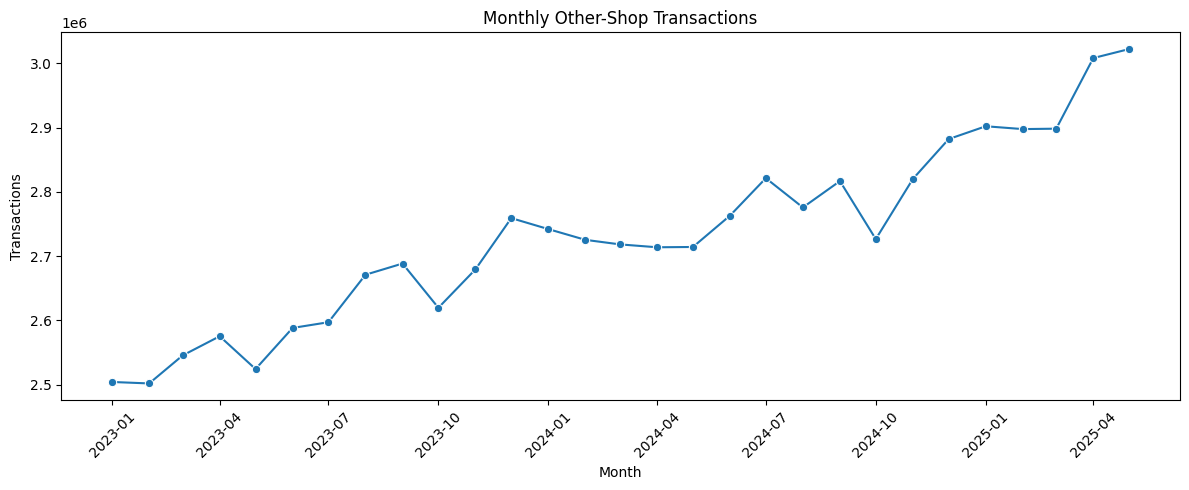

In [9]:
import seaborn as sns 
import matplotlib.pyplot as plt

plt.figure(
    figsize=(12, 5)
)

sns.lineplot(
    data=portability_trend,
    x="period",
    y="other_shop_transactions",
    marker="o"
)

plt.title(
    "Monthly Other-Shop Transactions"
)

plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

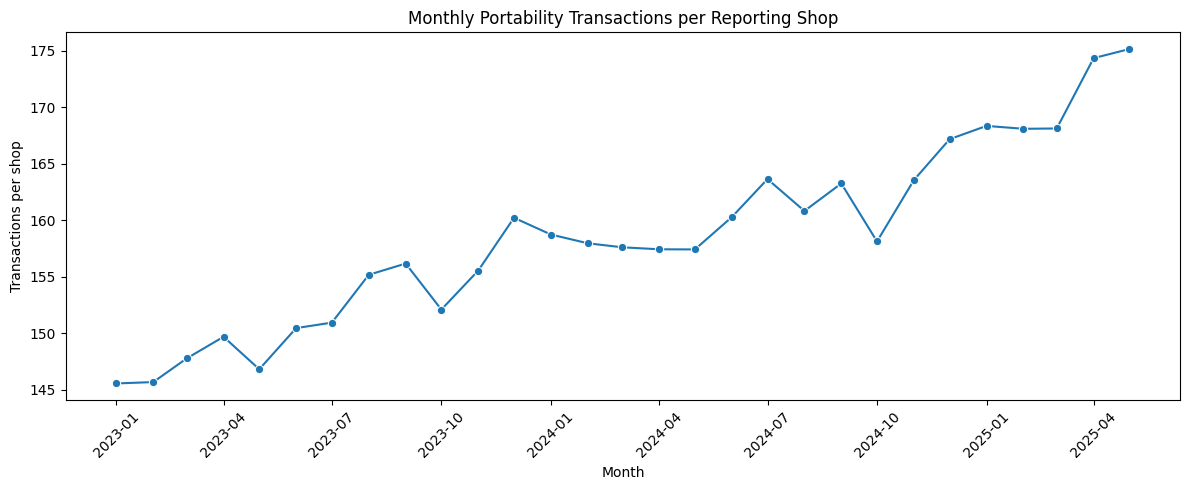

In [10]:
plt.figure(
    figsize=(12, 5)
)

sns.lineplot(
    data=portability_trend,
    x="period",
    y="portability_per_shop",
    marker="o"
)

plt.title(
    "Monthly Portability Transactions per Reporting Shop"
)

plt.xlabel("Month")
plt.ylabel("Transactions per shop")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#correlation analysis 
#between totalrcs vs nooftransactions 
#the first four are identifiers or identifiers the co relations 
# we may approach this drop all missing values form all columns , data looks weaker 
#focused dataframe 
correlation_data =monthly_data[
    [
        "distCode",      # once we know the relations naturally want to know the which shop or district 
        "shopNo",        # i used to put them as single bracket , but i wanna a dataframe as return or selcting multiole columnsd 
        "year",
        "month",
        "totalRcs",
        "noOfTrans"
    ]
    
].dropna(
    subset = ["totalRcs","noOfTrans"]
)


print("matched rows :", len(correlation_data))

correlation_data.head()

In [13]:
correlation_data[
    [
        "totalRcs",
        "noOfTrans"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
totalRcs,482261.0,522.595783,251.207063,18.0,360.0,483.0,631.0,5269.0
noOfTrans,482261.0,445.056036,270.847719,1.0,275.0,390.0,539.0,7089.0


In [ ]:
#check negative and zero analysis 

print ("negative card counts ", (correlation_data["totalRcs"]<0) .sum())  #pass a column , not a variable

print ("negative transactions counts ", (correlation_data["noOfTrans"]<0 ).sum()) # need to wrap a paranthesiss before the sum 

print ("zero count counts ", (correlation_data["totalRcs"]==0 ).sum())

negative card counts  0
negative transactions counts  0
zero count counts  0


In [17]:
#calculate correlation 

pearson_correlation = (
    correlation_data[
        ["totalRcs", "noOfTrans"]  # select momre than one column
    ]
    .corr(
        method="pearson"
    )
    .loc[
        "totalRcs",  #row labels
        "noOfTrans"   #row columns
    ]
)

spearman_correlation = (
    correlation_data[
        ["totalRcs", "noOfTrans"]
    ]
    .corr(
        method="spearman"
    )
    .loc[
        "totalRcs",
        "noOfTrans"
    ]
)

print(
    "Pearson correlation:",
    round(
        pearson_correlation,
        3   #round the correlaation coefficeint to 3  decimal places 
    )
)

print(
    "Spearman correlation:",
    round(
        spearman_correlation,
        3
    )
)

Pearson correlation: 0.88
Spearman correlation: 0.899


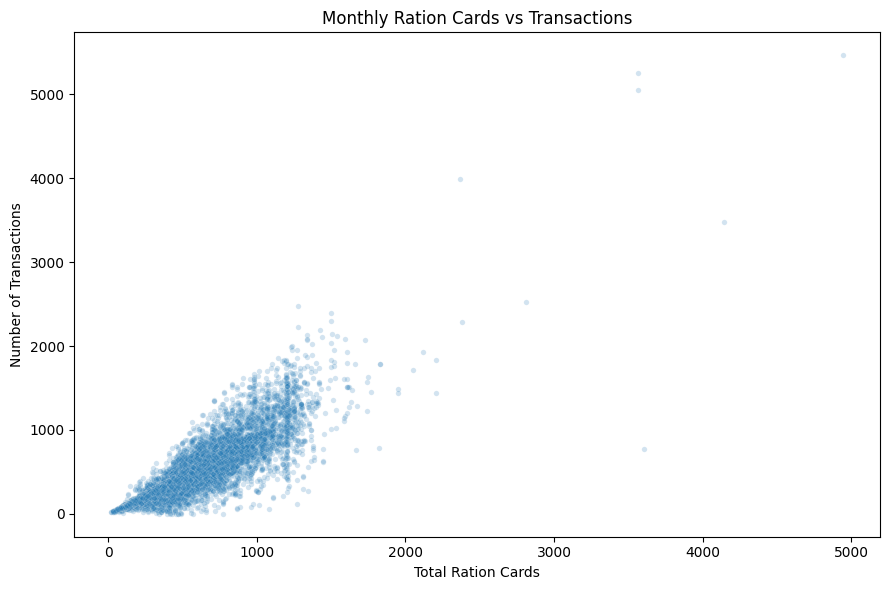

In [19]:
#plot a sample 

plot_data = correlation_data.sample (n=min(20000,len(correlation_data)),random_state=42)


plt.figure(
    figsize=(9, 6)
)

sns.scatterplot(
    data=plot_data,
    x="totalRcs",
    y="noOfTrans",
    alpha=0.20,
    s=15
)

plt.title(
    "Monthly Ration Cards vs Transactions"
)

plt.xlabel(
    "Total Ration Cards"
)

plt.ylabel(
    "Number of Transactions"
)

plt.tight_layout()
plt.show()

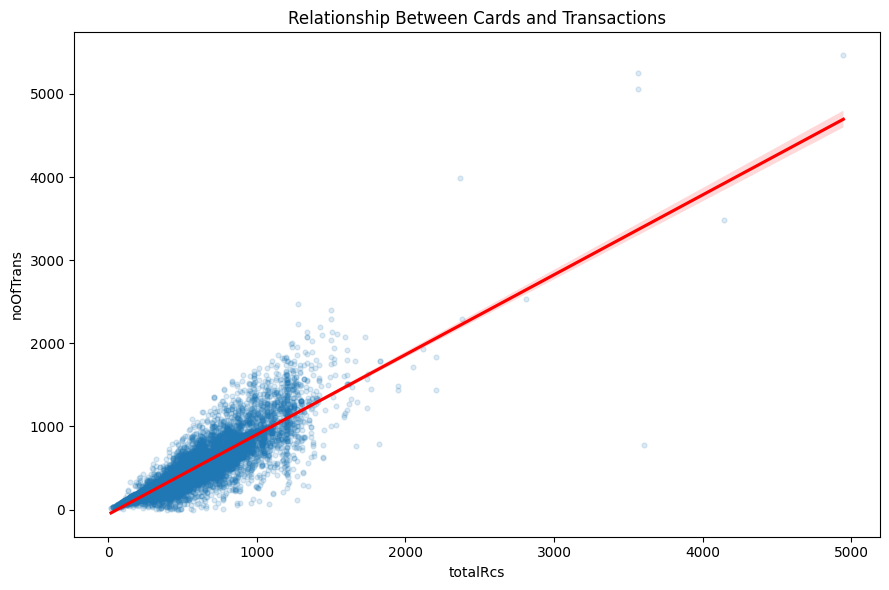

In [20]:
plt.figure(
    figsize=(9, 6)
)

sns.regplot(
    data=plot_data,
    x="totalRcs",
    y="noOfTrans",
    scatter_kws={
        "alpha": 0.15,
        "s": 12
    },
    line_kws={
        "color": "red"
    }
)

plt.title(
    "Relationship Between Cards and Transactions"
)

plt.tight_layout()
plt.show()

In [ ]:
#check invalid quantities 
print(transaction_data[
    [
        "total_rice",
        "wheat"
    ]
].head())

#commodity summary 

commodity_summary =(transaction_data[
    [
        "total_rice",
        "wheat"
    ]
].describe().T)
print(commodity_summary)

#check invalid quantities 

print("Negative   rice values:" ,(transaction_data["total_rice"]<0 ).sum())
print("Negative   wheat values:" ,(transaction_data["wheat"]<0 ).sum())
print("zero rice values:" ,(transaction_data["total_rice"]==0 ).sum())
print("zero wheat values:" ,(transaction_data["wheat"]==0 ).sum())


   total_rice  wheat
0      5355.0    0.0
1      6781.0    0.0
2      6910.0    0.0
3      5750.0    0.0
4      7169.0    0.0
               count         mean          std  min     25%     50%      75%  \
total_rice  499648.0  9115.260485  5935.230236  0.0  5515.0  7809.0  10854.0   
wheat       499648.0   195.216270   802.106118  0.0     0.0     0.0      0.0   

                 max  
total_rice  149655.0  
wheat        11862.0  
Negative   rice values: 0
Negative   wheat values: 0
Negative  zero rice values: 1
Negative  zero wheat values: 461525


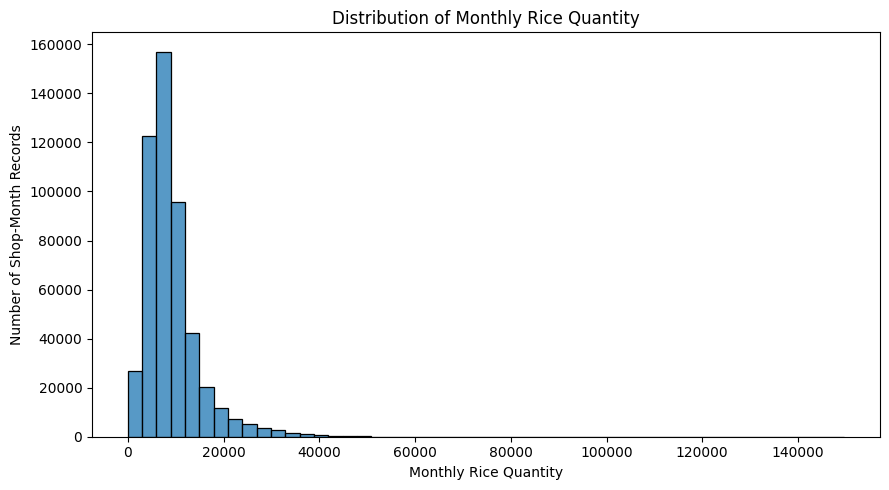

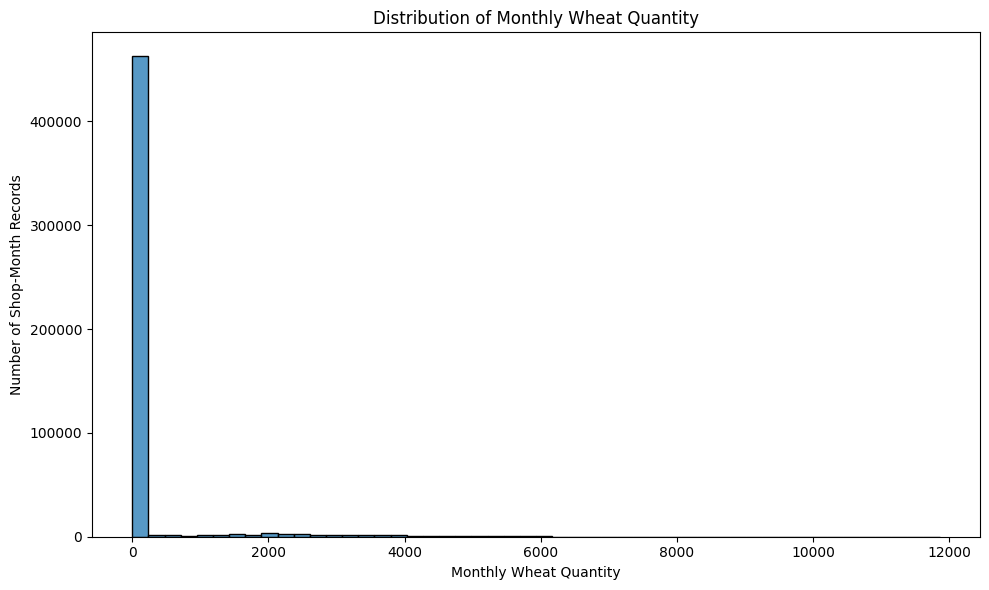

In [38]:
#perfoming histogram on rice and wheat 

plt.figure (figsize=(9,5)
)
sns.histplot(
    data=transaction_data,
    x="total_rice",
    bins=50 
)
plt.title("Distribution of Monthly Rice Quantity")
plt.xlabel(
    "Monthly Rice Quantity"
)

plt.ylabel(
    "Number of Shop-Month Records"
)

plt.tight_layout()
plt.show()


#wheat 
plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    data=transaction_data,
    x="wheat",
    bins=50
)

plt.title(
    "Distribution of Monthly Wheat Quantity"
)

plt.xlabel(
    "Monthly Wheat Quantity"
)

plt.ylabel(
    "Number of Shop-Month Records"
)

plt.tight_layout()
plt.show()


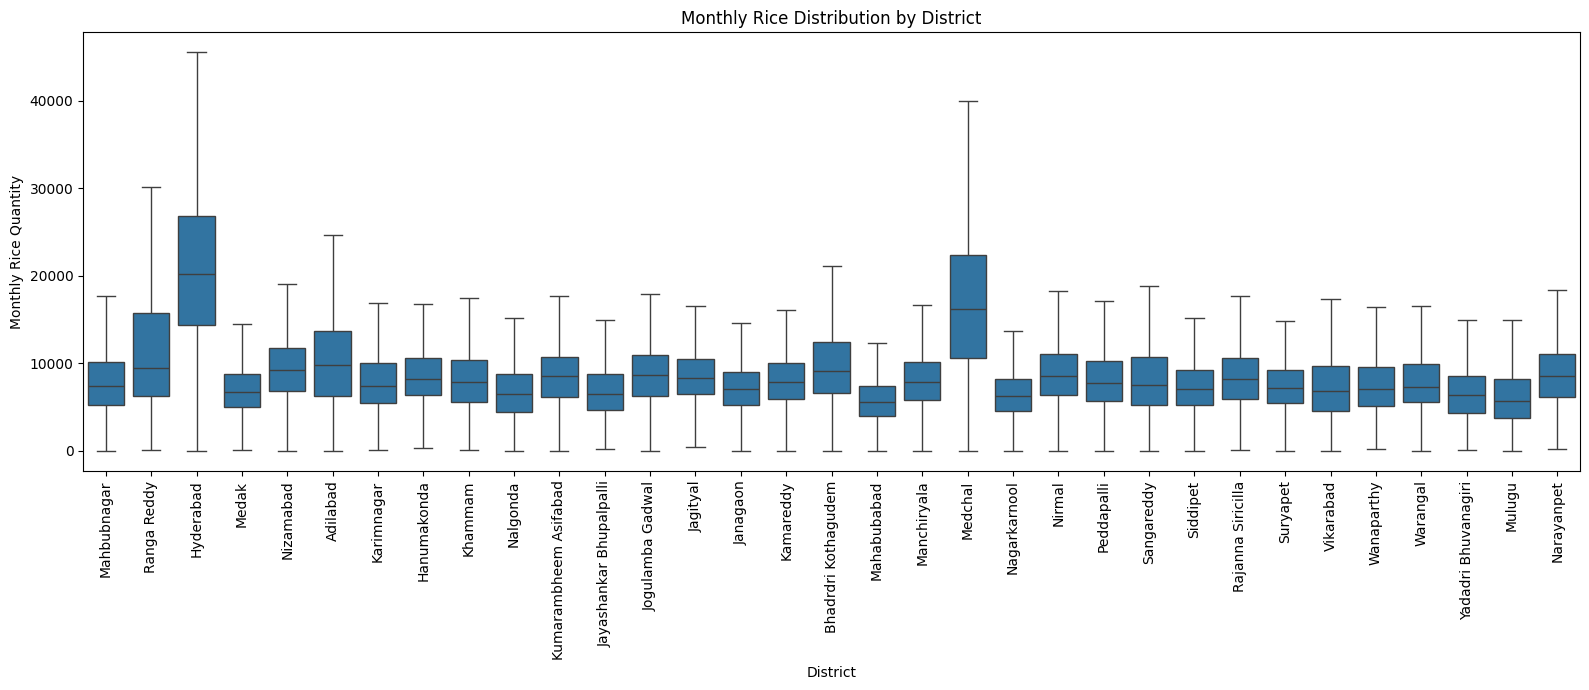

In [43]:
plt.figure(
    figsize=(16, 7)
)

sns.boxplot(
    data=transaction_data,
    x="distName",
    y="total_rice",
    showfliers=False
    
)

plt.title(
    "Monthly Rice Distribution by District"
)

plt.xlabel("District")
plt.ylabel("Monthly Rice Quantity")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:


#district summary 
district_commodity_summary = (
    transaction_data
    .groupby(
        "distName",
        as_index=False
    )
    .agg(
        average_rice=(
            "total_rice",
            "mean"
        ),

        median_rice=(
            "total_rice",
            "median"
        ),

        average_wheat=(
            "wheat",
            "mean"
        ),

        median_wheat=(
            "wheat",
            "median"
        ),

        reporting_rows=(
            "shopNo",
            "count"
        )
    )
    .sort_values(
        "median_rice",
        ascending=False
    )
)

district_commodity_summary

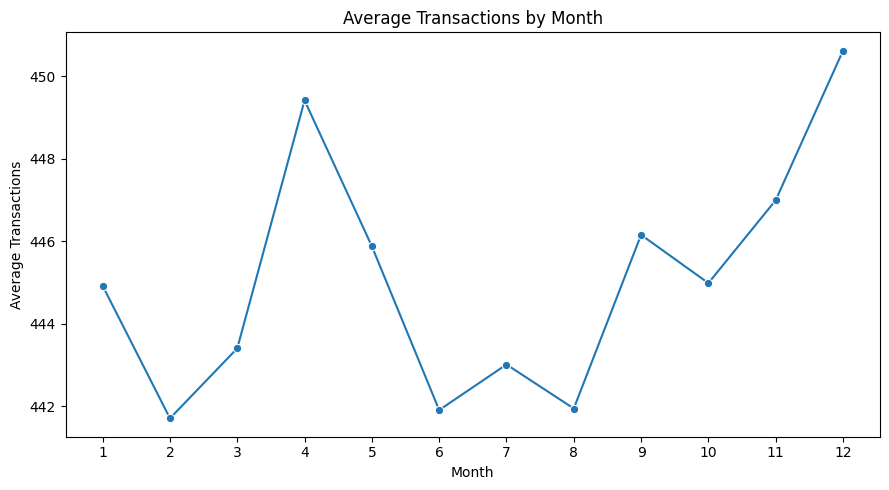

Highest transaction month: 12
Highest monthly average: 450.62
Lowest transaction month: 2
Lowest monthly average: 441.7


In [48]:
# finding seasonality spikes 

monthly_seasonality = (
    transaction_data
    .groupby(
        "month",
        as_index=False
    )
    .agg(
        average_transactions=(
            "noOfTrans",
            "mean"
        ),

        total_transactions=(
            "noOfTrans",
            "sum"
        )
    )
)

monthly_seasonality



#plot the data 

plt.figure(
    figsize=(9, 5)
)

sns.lineplot(
    data=monthly_seasonality,
    x="month",
    y="average_transactions",
    marker="o"
)

plt.title(
    "Average Transactions by Month"
)

plt.xlabel("Month")
plt.ylabel("Average Transactions")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


highest_month = monthly_seasonality.loc[
    monthly_seasonality[
        "average_transactions"
    ].idxmax()
]

lowest_month = monthly_seasonality.loc[
    monthly_seasonality[
        "average_transactions"
    ].idxmin()
]

print(
    "Highest transaction month:",
    int(highest_month["month"])
)

print(
    "Highest monthly average:",
    round(
        highest_month[
            "average_transactions"
        ],
        2
    )
)

print(
    "Lowest transaction month:",
    int(lowest_month["month"])
)

print(
    "Lowest monthly average:",
    round(
        lowest_month[
            "average_transactions"
        ],
        2
    )
)


Lower limit: -121.0
Upper limit: 935.0
Number of outlier records: 26134
Outlier percentage: 5.23 %


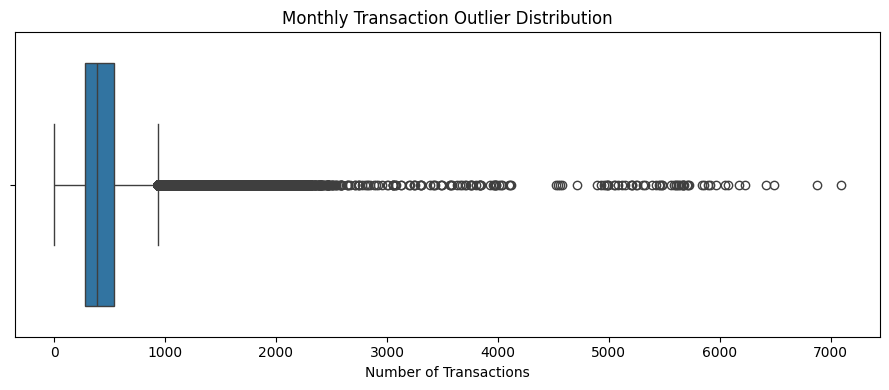

In [53]:
#transaction outlier 
Q1 = transaction_data[
    "noOfTrans"
].quantile(0.25)

Q3 = transaction_data[
    "noOfTrans"
].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(
    "Lower limit:",
    lower_limit
)

print(
    "Upper limit:",
    upper_limit
)

transaction_outliers = transaction_data[
    (
        transaction_data["noOfTrans"]
        < lower_limit
    )
    |
    (
        transaction_data["noOfTrans"]
        > upper_limit
    )
].copy()

print(
    "Number of outlier records:",
    len(transaction_outliers)
)

print(
    "Outlier percentage:",
    round(
        len(transaction_outliers)
        / len(transaction_data)
        * 100,
        2
    ),
    "%"
)

transaction_outliers[
    [
        "distCode",
        "distName",
        "shopNo",
        "year",
        "month",
        "noOfTrans",
        "totalRcs",
        "otherShopTransCnt"
    ]
].sort_values(
    "noOfTrans",
    ascending=False
).head(20)


plt.figure(
    figsize=(9, 4)
)

sns.boxplot(
    data=transaction_data,
    x="noOfTrans"
)

plt.title(
    "Monthly Transaction Outlier Distribution"
)

plt.xlabel(
    "Number of Transactions"
)

plt.tight_layout()
plt.show()